# Creates Two Figures 
1. Figure. Arizona Post-Secondary Training and Occupational Alignment for Select Years
2. Figure. 2025 Related Completions Pipeline Share by Sector and Institution Type 


# Figure. Arizona Post-Secondary Training and Occupational Alignment for Select Years

## What this figure measures

This notebook creates the **occupation-level scatterplot used in the manuscript**.

Each point is one selected **5-star occupation**.

- **X-axis:** percentage growth in Maricopa County occupation employment from **2014 to 2025**
- **Y-axis:** percentage growth in **related IPEDS completions** from **2014 to 2025**
- **Dashed 45-degree line:** where training growth and employment growth are equal
- Points **above** the line indicate related completions grew faster than employment.
- Points **below** the line indicate employment grew faster than related completions.

This is a descriptive alignment measure. It is **not** a shortage estimate and does not show that graduates entered a specific occupation.

---

## Geography

Both sides of this figure are aligned to the Greater Phoenix analysis:

- **IPEDS:** institutions in the Maricopa County project extract
- **Lightcast employment:** Maricopa County occupation employment

The figure should therefore be interpreted as a **Maricopa County / Greater Phoenix training-to-employment alignment analysis**.

---

## Occupation universe

The occupation universe comes from:

`Master_CIP_SOC_Matched_Output_3.xlsx`

Only occupations with:

`Sum of Occupation Rating by Ed Lvl1 == 5`

are included.

Sector display order:

1. Healthcare and Social Assistance
2. Manufacturing
3. Construction
4. Semiconductors

### Semiconductor definition

Semiconductors are identified directly from:

`Semiconductor Flag == "Yes"`

The current master file should contain **4 five-star Semiconductor occupations**.

Semiconductor occupations are plotted as their own group and are not plotted a second time as Manufacturing points.

---

## Data sources used

### 1. `Master_CIP_SOC_Matched_Output_3.xlsx`
Current source of truth for:
- selected occupations
- star ratings
- sector assignments
- Semiconductor flag
- CIP-to-SOC relationships
- occupation titles

### 2. IPEDS completion files
Postsecondary completions by CIP for:
- 2014
- 2019
- 2025

The figure itself uses **2014 and 2025** for the growth calculation.  
2019 is retained in the output workbook for review and longitudinal context.

### 3. `Crosswalk.csv`
Used to harmonize older **2010 CIP codes** to the current CIP classification before matching them to the current master CIP-to-SOC relationships.

### 4. Lightcast occupation employment files
Maricopa County occupation employment for:
- 2014
- 2019
- 2025

The notebook identifies the correct Lightcast file by looking for the corresponding `2014 Jobs`, `2019 Jobs`, or `2025 Jobs` column rather than relying on a download filename.

---

## Related completions

A CIP can map to more than one occupation.

For this manuscript figure, **related completions** are calculated by summing all IPEDS completions from CIPs mapped to each occupation.

This should be described as **related completions**, not:
- workers trained for the occupation,
- graduates entering the occupation, or
- unique labor supply.

---

## Community college vs. university

This figure **combines all postsecondary completions** in the IPEDS extract. It does not split community colleges and universities.

If a community-college-versus-university comparison is needed, it should be created as a separate table or sensitivity analysis rather than changing the meaning of this figure.


## Institution-type breakdown

In addition to the combined postsecondary pipeline used in the main manuscript scatterplot, this notebook now preserves a three-category institution breakdown:

1. **Community College**
2. **University**
3. **Other**

### Classification method

The supplied IPEDS completion files contain `unitid` and `institution name`, but they do not contain a direct institutional-sector field in this extract.

For this analysis, institutions are therefore classified consistently from `institution name`.

- **Community College** includes the Maricopa community colleges represented in the extract.
- **University** includes institutions whose official IPEDS institution name identifies them as a university.
- **Other** includes career/technical colleges, specialty schools, nursing and medical institutes, trade schools, beauty schools, seminaries, and other postsecondary providers that are neither Community Colleges nor Universities.

A QA table containing every institution and its assigned category is exported with the results so the classification remains transparent and editable.

### Important interpretation note

The main manuscript scatterplot continues to use **all postsecondary completions combined**, preserving the original meaning of the figure.

The institution-type breakdown is exported as supporting analysis so reviewers can determine whether changes in the training pipeline are being driven primarily by Community Colleges, Universities, or Other providers.


In [4]:
# ============================================================
# 1. SETTINGS — CHANGE ONLY COMPUTER IF NEEDED
# ============================================================

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

# ------------------------------------------------------------
# COMPUTER
# ------------------------------------------------------------
# "W" = work computer
# "P" = personal computer
# "S" = use the Shared Drive as the working source folder
COMPUTER = "W"

# ------------------------------------------------------------
# CURRENT MASTER FILE
# ------------------------------------------------------------

MASTER_PATHS = {
    "W": Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        r"\Master_CIP_SOC_Matched_Output_3.xlsx"
    ),

    "P": Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
        r"\Master_CIP_SOC_Matched_Output_3.xlsx"
    ),

    "S": Path(
        r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
        r"\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python"
        r"\Master_CIP_SOC_Matched_Output_3.xlsx"
    ),
}

BASE_FOLDERS = {
    "W": Path(
        r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
    ),

    "P": Path(
        r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
    ),

    "S": Path(
        r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
        r"\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python"
    ),
}

OUTPUT_FOLDER = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Excel Sheets\Arielle Tables"
)

key = str(COMPUTER).strip().upper()

if key not in MASTER_PATHS:
    raise ValueError('COMPUTER must be "W", "P", or "S".')

MASTER_FILE = MASTER_PATHS[key]
BASE_FOLDER = BASE_FOLDERS[key]

# ------------------------------------------------------------
# SUPPORTING FILES
# ------------------------------------------------------------

CROSSWALK_FILE = BASE_FOLDER / "Crosswalk.csv"

IPEDS_FILES = {
    2014: BASE_FOLDER / "CSV_9242026-348.csv",
    2019: BASE_FOLDER / "CSV_9242026-710.csv",
    2025: BASE_FOLDER / "CSV_9202026-120.csv",
}

YEARS = [2014, 2019, 2025]

# ------------------------------------------------------------
# OUTPUT FILES
# ------------------------------------------------------------

OUTPUT_EXCEL = (
    OUTPUT_FOLDER
    / "Figure_Postsecondary_Training_Occupational_Alignment.xlsx"
)

OUTPUT_PNG = (
    OUTPUT_FOLDER
    / "Figure_Postsecondary_Training_Occupational_Alignment.png"
)

# ------------------------------------------------------------
# FIGURE DISPLAY
# ------------------------------------------------------------

# Nurse Practitioners was excluded from the manuscript display because
# its very large growth value compressed the rest of the occupation points.
# The occupation remains in the exported data.
EXCLUDE_FROM_DISPLAY = {
    "Nurse Practitioners"
}

# Additional extreme observations can be excluded from the plotted display
# if either axis exceeds this absolute percentage-growth threshold.
# They remain in the Excel output.
DISPLAY_GROWTH_LIMIT = 500

SECTOR_ORDER = [
    "Healthcare and Social Assistance",
    "Manufacturing",
    "Construction",
    "Semiconductors",
]

FIVE_STAR_VALUE = 5

print("Computer:", key)
print("Master:", MASTER_FILE)
print("Base folder:", BASE_FOLDER)
print("Output folder:", OUTPUT_FOLDER)


Computer: W
Master: C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_3.xlsx
Base folder: C:\Users\301533\Documents\Walmart\IPEDS\Files
Output folder: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables


In [5]:
# ============================================================
# 2. HELPERS
# ============================================================

def clean_soc(value):
    """Standardize SOC codes to ##-####."""

    if pd.isna(value):
        return np.nan

    digits = re.sub(
        r"\D",
        "",
        str(value)
    )

    if len(digits) >= 6:
        return f"{digits[:2]}-{digits[2:6]}"

    return np.nan


def clean_cip(value):
    """Standardize detailed CIP codes to ##.####."""

    if pd.isna(value):
        return np.nan

    original_is_numeric = isinstance(
        value,
        (int, float, np.integer, np.floating)
    )

    text = (
        str(value)
        .strip()
        .replace('="', "")
        .replace('"', "")
        .replace("'", "")
    )

    text = re.sub(
        r"[^0-9.]",
        "",
        text
    )

    if not text:
        return np.nan

    if "." in text:

        left, right = text.split(".", 1)

        right = re.sub(
            r"\D",
            "",
            right
        )

        if original_is_numeric and 1 <= len(right) <= 4:
            return (
                f"{left.zfill(2)}."
                f"{right.ljust(4, '0')[:4]}"
            )

        if len(right) >= 4:
            return (
                f"{left.zfill(2)}."
                f"{right[:4]}"
            )

    digits = re.sub(
        r"\D",
        "",
        text
    )

    if len(digits) == 6:
        return f"{digits[:2]}.{digits[2:]}"

    return np.nan


def pct_change(old_value, new_value):
    """Percent change from old_value to new_value."""

    if (
        pd.isna(old_value)
        or pd.isna(new_value)
        or old_value == 0
    ):
        return np.nan

    return (
        (new_value - old_value)
        / old_value
        * 100
    )


def first_existing(columns, candidates):
    """Return the first candidate column that exists."""

    for column in candidates:
        if column in columns:
            return column

    return None


## 3. Select the current 5-star occupation universe

The current master workbook replaces the older hard-coded Healthcare/Manufacturing occupation lists.

For this figure:

- Healthcare comes from `Industry = Healthcare`
- Manufacturing comes from `Industry = Manufacturing`
- Construction comes from `Industry = Construction`
- Semiconductor occupations come from `Semiconductor Flag = Yes`
- All occupations must have a star rating of **5**

To avoid double-counting a point, a Semiconductor-flagged occupation is displayed as **Semiconductors**, not again as Manufacturing.


In [6]:
# ============================================================
# 3. LOAD CURRENT MASTER AND DEFINE OCCUPATIONS
# ============================================================

if not MASTER_FILE.exists():
    raise FileNotFoundError(
        f"Master workbook not found:\n{MASTER_FILE}"
    )

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
).copy()

required_master_columns = [
    "SOC_Code",
    "Job Title",
    "Sum of Occupation Rating by Ed Lvl1",
    "Industry",
    "Semiconductor Flag",
    "CIP_Code",
    "CIP_Title",
]

missing = [
    column
    for column in required_master_columns
    if column not in master.columns
]

if missing:
    raise KeyError(
        f"Master workbook is missing required columns: {missing}"
    )

master["soc"] = master["SOC_Code"].map(clean_soc)

master["stars"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)

master["semiconductor_yes"] = (
    master["Semiconductor Flag"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("yes")
)

master["cip_current"] = master["CIP_Code"].map(
    clean_cip
)

selected = master[
    master["stars"].eq(FIVE_STAR_VALUE)
    & master["soc"].notna()
].copy()

# Assign one display sector to each occupation.
selected["sector"] = np.select(
    [
        selected["semiconductor_yes"],
        selected["Industry"].eq("Healthcare"),
        selected["Industry"].eq("Manufacturing"),
        selected["Industry"].eq("Construction"),
    ],
    [
        "Semiconductors",
        "Healthcare and Social Assistance",
        "Manufacturing",
        "Construction",
    ],
    default=None  # Changed from np.nan to default=None to prevent DType mismatch
)

selected = selected[
    selected["sector"].isin(SECTOR_ORDER)
].copy()

occupation_universe = (
    selected[
        [
            "sector",
            "soc",
            "Job Title",
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "Job Title": "job_title"
        }
    )
)

occupation_universe["sector"] = pd.Categorical(
    occupation_universe["sector"],
    categories=SECTOR_ORDER,
    ordered=True
)

occupation_universe = occupation_universe.sort_values(
    ["sector", "soc"]
).reset_index(drop=True)

sector_counts = (
    occupation_universe
    .groupby(
        "sector",
        observed=False
    )["soc"]
    .nunique()
    .reindex(SECTOR_ORDER)
)

print("5-star occupation counts used in the figure:")
print(sector_counts)

if int(sector_counts.loc["Semiconductors"]) != 4:
    raise ValueError(
        "Expected exactly 4 five-star Semiconductor occupations. "
        "Review Semiconductor Flag in the current master workbook."
    )

display(occupation_universe)

5-star occupation counts used in the figure:
sector
Healthcare and Social Assistance    25
Manufacturing                        7
Construction                         9
Semiconductors                       4
Name: soc, dtype: int64


,sector,soc,job_title
0,Healthcare and Social Assistance,21-1094,Community Health Workers
1,Healthcare and Social Assistance,29-1021,"Dentists, General"
2,Healthcare and Social Assistance,29-1041,Optometrists
3,Healthcare and Social Assistance,29-1071,Physician Assistants
4,Healthcare and Social Assistance,29-1122,Occupational Therapists
5,Healthcare and Social Assistance,29-1123,Physical Therapists
6,Healthcare and Social Assistance,29-1126,Respiratory Therapists
7,Healthcare and Social Assistance,29-1127,Speech-Language Pathologists
8,Healthcare and Social Assistance,29-1141,Registered Nurses
9,Healthcare and Social Assistance,29-1151,Nurse Anesthetists


## 4. Build current CIP-to-SOC relationships

The master workbook is the source of the occupation-to-program relationships.

Each detailed CIP linked to a selected occupation is retained once for that occupation. The same CIP can legitimately be related to more than one occupation; therefore the resulting completion measure is called **related completions**.


In [7]:
# ============================================================
# 4. CURRENT CIP -> SOC RELATIONSHIPS
# ============================================================

cip_soc = (
    selected[
        [
            "sector",
            "soc",
            "Job Title",
            "cip_current",
            "CIP_Title",
        ]
    ]
    .rename(
        columns={
            "Job Title": "job_title",
            "CIP_Title": "cip_title",
        }
    )
    .dropna(
        subset=["cip_current"]
    )
    .drop_duplicates(
        ["sector", "soc", "cip_current"]
    )
    .copy()
)

print(
    "CIP-to-SOC relationships:",
    len(cip_soc)
)

print(
    "Unique current CIPs:",
    cip_soc["cip_current"].nunique()
)

display(
    cip_soc.head(20)
)


CIP-to-SOC relationships: 81
Unique current CIPs: 72


,sector,soc,job_title,cip_current,cip_title
2,Healthcare and Social Assistance,35-2012,"Cooks, Institution and Cafeteria",12.0500,"Cooking and Related Culinary Arts, General."
3,Healthcare and Social Assistance,35-2012,"Cooks, Institution and Cafeteria",19.0505,Foodservice Systems Administration/Management.
14,Healthcare and Social Assistance,29-1021,"Dentists, General",51.0401,Dentistry.
15,Healthcare and Social Assistance,29-1021,"Dentists, General",51.0502,Advanced General Dentistry.
16,Healthcare and Social Assistance,29-1021,"Dentists, General",60.0102,Dental Public Health Residency Program.
18,Healthcare and Social Assistance,53-2012,Commercial Pilots,49.0102,Airline/Commercial/Professional Pilot and Flig...
20,Healthcare and Social Assistance,21-1094,Community Health Workers,09.0905,Health Communication.
21,Healthcare and Social Assistance,21-1094,Community Health Workers,51.0001,"Health and Wellness, General."
22,Healthcare and Social Assistance,21-1094,Community Health Workers,51.1504,Community Health Services/Liaison/Counseling.
23,Healthcare and Social Assistance,21-1094,Community Health Workers,51.2201,"Public Health, General."


## 5. Harmonize older IPEDS CIP codes

The 2014 and 2019 IPEDS files use the 2010 CIP classification. The current master uses the current CIP classification.

`Crosswalk.csv` is therefore used to convert the older detailed CIP codes before they are matched to the current master relationships. The 2025 IPEDS file already uses the current classification.


In [8]:
# ============================================================
# 5. LOAD CIP CROSSWALK
# ============================================================

if not CROSSWALK_FILE.exists():
    raise FileNotFoundError(
        f"CIP crosswalk not found:\n{CROSSWALK_FILE}"
    )

crosswalk = pd.read_csv(
    CROSSWALK_FILE,
    dtype=str
)

required_crosswalk_columns = {
    "Original code",
    "Current code",
}

if not required_crosswalk_columns.issubset(
    crosswalk.columns
):
    raise KeyError(
        "Crosswalk.csv must contain 'Original code' "
        "and 'Current code'."
    )

crosswalk["cip_2010"] = (
    crosswalk["Original code"]
    .map(clean_cip)
)

crosswalk["cip_current"] = (
    crosswalk["Current code"]
    .map(clean_cip)
)

detailed_crosswalk = (
    crosswalk
    .dropna(
        subset=[
            "cip_2010",
            "cip_current"
        ]
    )
    .drop_duplicates(
        [
            "cip_2010",
            "cip_current"
        ]
    )
)

crosswalk_conflicts = (
    detailed_crosswalk
    .groupby("cip_2010")["cip_current"]
    .nunique()
    .reset_index(
        name="current_code_count"
    )
)

crosswalk_conflicts = crosswalk_conflicts[
    crosswalk_conflicts[
        "current_code_count"
    ] > 1
]

if not crosswalk_conflicts.empty:
    raise ValueError(
        "The detailed CIP crosswalk contains one-to-many mappings. "
        "Review Crosswalk.csv before continuing."
    )

CIP_2010_TO_CURRENT = (
    detailed_crosswalk
    .drop_duplicates("cip_2010")
    .set_index("cip_2010")["cip_current"]
    .to_dict()
)

print(
    "Detailed CIP mappings loaded:",
    f"{len(CIP_2010_TO_CURRENT):,}"
)


Detailed CIP mappings loaded: 1,720


## 6. Load IPEDS completions

The IPEDS files provide postsecondary completion counts by CIP.

The workflow:
1. detects the detailed CIP and completion columns,
2. keeps **first majors** when the first/second-major field is present,
3. aggregates completions to CIP and year,
4. converts 2014 and 2019 CIPs to the current classification,
5. matches the resulting CIPs to the selected occupations.

The figure uses the total related completions for each occupation.


In [9]:
# ============================================================
# INSTITUTION TYPE CLASSIFICATION
# ============================================================
#
# The IPEDS extract contains institution name and UNITID but does
# not contain a direct Community College / University field.
#
# Classification is therefore based on the official institution
# name appearing in the IPEDS file.
#
# Categories:
#   1. Community College
#   2. University
#   3. Other
#
# The full institution classification is exported for QA.
# ============================================================

COMMUNITY_COLLEGES = {
    "Chandler-Gilbert Community College",
    "Estrella Mountain Community College",
    "GateWay Community College",
    "GateWay Community College-Central City",
    "Glendale Community College",
    "Mesa Community College",
    "Paradise Valley Community College",
    "Phoenix College",
    "Rio Salado College",
    "Scottsdale Community College",
    "South Mountain Community College",
}


def classify_institution(institution_name):
    """
    Classify an IPEDS institution into one of three groups.

    Community College:
        Explicit list of Maricopa community colleges represented
        in the project IPEDS extract.

    University:
        Official institution name contains the word "University".

    Other:
        All other postsecondary providers in the extract.
    """

    if pd.isna(institution_name):
        return "Other"

    name = str(institution_name).strip()

    if name in COMMUNITY_COLLEGES:
        return "Community College"

    if "university" in name.casefold():
        return "University"

    return "Other"


INSTITUTION_TYPE_ORDER = [
    "Community College",
    "University",
    "Other",
]


In [10]:
# ============================================================
# 6. LOAD AND STANDARDIZE IPEDS
# ============================================================

def detect_ipeds_columns(df):

    columns = list(df.columns)

    cip_col = first_existing(
        columns,
        [
            "C2025_A.CIP Code -  2020 Classification",
            "C2019_A.CIP Code -  2010 Classification",
            "C2014_A.CIP Code -  2010 Classification",
            "CIP Code",
            "CIPCODE",
            "CIP",
        ]
    )

    if cip_col is None:
        possible = [
            c for c in columns
            if "cip" in c.lower()
            and "title" not in c.lower()
        ]
        if possible:
            cip_col = possible[0]

    major_col = first_existing(
        columns,
        [
            "C2025_A.First or Second Major",
            "C2019_A.First or Second Major",
            "C2014_A.First or Second Major",
            "First or Second Major",
        ]
    )

    institution_col = first_existing(
        columns,
        [
            "institution name",
            "Institution Name",
            "INSTNM",
        ]
    )

    unitid_col = first_existing(
        columns,
        [
            "unitid",
            "UNITID",
            "UnitID",
        ]
    )

    total_cols = [
        c for c in columns
        if "grand total" in c.lower()
    ]

    completions_col = (
        total_cols[0]
        if total_cols
        else None
    )

    return {
        "cip": cip_col,
        "major": major_col,
        "institution": institution_col,
        "unitid": unitid_col,
        "completions": completions_col,
    }


ipeds_parts = []
ipeds_qa_rows = []


for year, path in IPEDS_FILES.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Missing {year} IPEDS file:\n{path}"
        )

    df = pd.read_csv(
        path,
        low_memory=False
    )

    detected = detect_ipeds_columns(df)

    if detected["cip"] is None:
        raise ValueError(
            f"Could not identify the CIP column for {year}."
        )

    if detected["completions"] is None:
        raise ValueError(
            f"Could not identify the completion-count column for {year}."
        )

    if detected["institution"] is None:
        raise ValueError(
            f"Could not identify the institution-name column for {year}. "
            "Institution type cannot be classified."
        )

    if detected["major"] is not None:

        major_text = (
            df[detected["major"]]
            .astype(str)
            .str.strip()
            .str.casefold()
        )

        if major_text.str.contains(
            "first",
            na=False
        ).any():

            df = df[
                major_text.str.contains(
                    "first",
                    na=False
                )
            ].copy()

    df["institution_name"] = (
        df[detected["institution"]]
        .astype(str)
        .str.strip()
    )

    if detected["unitid"] is not None:
        df["unitid_clean"] = df[detected["unitid"]]
    else:
        df["unitid_clean"] = np.nan

    df["institution_type"] = (
        df["institution_name"]
        .map(classify_institution)
    )

    df["cip_original"] = (
        df[detected["cip"]]
        .map(clean_cip)
    )

    df["completers"] = pd.to_numeric(
        df[detected["completions"]],
        errors="coerce"
    ).fillna(0)

    if year in {2014, 2019}:

        df["cip_current"] = (
            df["cip_original"]
            .map(CIP_2010_TO_CURRENT)
        )

    else:

        df["cip_current"] = (
            df["cip_original"]
        )

    df["year"] = year

    ipeds_qa_rows.append(
        {
            "year": year,
            "source_file": path.name,
            "rows_after_first_major_filter": len(df),
            "unique_institutions": df["institution_name"].nunique(),
            "community_college_institutions": (
                df.loc[
                    df["institution_type"].eq("Community College"),
                    "institution_name"
                ].nunique()
            ),
            "university_institutions": (
                df.loc[
                    df["institution_type"].eq("University"),
                    "institution_name"
                ].nunique()
            ),
            "other_institutions": (
                df.loc[
                    df["institution_type"].eq("Other"),
                    "institution_name"
                ].nunique()
            ),
            "total_completers": df["completers"].sum(),
            "rows_with_original_cip": df["cip_original"].notna().sum(),
            "rows_with_current_cip": df["cip_current"].notna().sum(),
        }
    )

    ipeds_parts.append(
        df[
            [
                "year",
                "unitid_clean",
                "institution_name",
                "institution_type",
                "cip_original",
                "cip_current",
                "completers",
            ]
        ].copy()
    )


ipeds = pd.concat(
    ipeds_parts,
    ignore_index=True
)


ipeds["institution_type"] = pd.Categorical(
    ipeds["institution_type"],
    categories=INSTITUTION_TYPE_ORDER,
    ordered=True
)


ipeds_qa = pd.DataFrame(
    ipeds_qa_rows
)


institution_classification = (
    ipeds[
        [
            "unitid_clean",
            "institution_name",
            "institution_type",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "institution_type",
            "institution_name",
        ]
    )
    .reset_index(drop=True)
)


print("IPEDS source QA:")
display(ipeds_qa)

print("\nInstitution classification QA:")
display(institution_classification)


IPEDS source QA:


,year,source_file,rows_after_first_major_filter,unique_institutions,community_college_institutions,university_institutions,other_institutions,total_completers,rows_with_original_cip,rows_with_current_cip
0,2014,CSV_9242026-348.csv,1555,48,11,8,29,64680,1555,1555
1,2019,CSV_9242026-710.csv,2226,47,11,8,28,76476,2226,2226
2,2025,CSV_9202026-120.csv,4160,73,11,16,46,187019,4120,4120



Institution classification QA:


,unitid_clean,institution_name,institution_type
0,364025,Chandler-Gilbert Community College,Community College
1,384333,Estrella Mountain Community College,Community College
2,105145,GateWay Community College,Community College
3,246895,GateWay Community College-Central City,Community College
4,104708,Glendale Community College,Community College
...,...,...,...
68,106041,Universal Technical Institute of Arizona Inc,Other
69,105215,Universal Technical Institute-Phoenix,Other
70,495013,Western Maricopa Education Center,Other
71,498322,Xtylo Beauty And Barber College,Other


In [11]:
# ============================================================
# 7. AGGREGATE IPEDS TO CURRENT CIP / YEAR
# ============================================================

# ------------------------------------------------------------
# A. COMBINED POSTSECONDARY PIPELINE
# ------------------------------------------------------------

ipeds_cip = (
    ipeds
    .dropna(
        subset=["cip_current"]
    )
    .groupby(
        [
            "year",
            "cip_current",
        ],
        as_index=False,
        observed=False,
    )["completers"]
    .sum()
)


# Match current CIP-to-SOC relationships to each year's completions.
ipeds_soc = cip_soc.merge(
    ipeds_cip,
    on="cip_current",
    how="left"
)

ipeds_soc["completers"] = (
    ipeds_soc["completers"]
    .fillna(0)
)


# Ensure every selected occupation has a row in every analysis year.
occupation_year_grid = (
    occupation_universe
    .assign(_key=1)
    .merge(
        pd.DataFrame(
            {
                "year": YEARS,
                "_key": 1,
            }
        ),
        on="_key"
    )
    .drop(
        columns="_key"
    )
)


related_completions = (
    ipeds_soc
    .groupby(
        [
            "sector",
            "soc",
            "job_title",
            "year",
        ],
        as_index=False,
        observed=False,
    )["completers"]
    .sum()
    .rename(
        columns={
            "completers":
                "related_completions"
        }
    )
)


education = (
    occupation_year_grid
    .merge(
        related_completions,
        on=[
            "sector",
            "soc",
            "job_title",
            "year",
        ],
        how="left"
    )
)


education[
    "related_completions"
] = education[
    "related_completions"
].fillna(0)


# ------------------------------------------------------------
# B. INSTITUTION-TYPE BREAKDOWN
# ------------------------------------------------------------
#
# Preserve exactly the same CIP->SOC method but aggregate completions
# separately for:
#   Community College
#   University
#   Other
# ------------------------------------------------------------

ipeds_cip_type = (
    ipeds
    .dropna(
        subset=["cip_current"]
    )
    .groupby(
        [
            "year",
            "institution_type",
            "cip_current",
        ],
        as_index=False,
        observed=False,
    )["completers"]
    .sum()
)


ipeds_soc_type = cip_soc.merge(
    ipeds_cip_type,
    on="cip_current",
    how="left"
)


ipeds_soc_type["completers"] = (
    ipeds_soc_type["completers"]
    .fillna(0)
)


institution_type_grid = (
    occupation_universe
    .assign(_key=1)
    .merge(
        pd.DataFrame(
            {
                "year": YEARS,
                "_key": 1,
            }
        ),
        on="_key"
    )
    .merge(
        pd.DataFrame(
            {
                "institution_type": INSTITUTION_TYPE_ORDER,
                "_key": 1,
            }
        ),
        on="_key"
    )
    .drop(
        columns="_key"
    )
)


related_completions_by_type = (
    ipeds_soc_type
    .groupby(
        [
            "sector",
            "soc",
            "job_title",
            "year",
            "institution_type",
        ],
        as_index=False,
        observed=False,
    )["completers"]
    .sum()
    .rename(
        columns={
            "completers":
                "related_completions"
        }
    )
)


education_by_type = (
    institution_type_grid
    .merge(
        related_completions_by_type,
        on=[
            "sector",
            "soc",
            "job_title",
            "year",
            "institution_type",
        ],
        how="left"
    )
)


education_by_type[
    "related_completions"
] = education_by_type[
    "related_completions"
].fillna(0)


print("Combined occupation/year education pipeline:")
display(
    education.head(20)
)

print("\nOccupation/year education pipeline by institution type:")
display(
    education_by_type.head(30)
)


Combined occupation/year education pipeline:


,sector,soc,job_title,year,related_completions
0,Healthcare and Social Assistance,21-1094,Community Health Workers,2014,146.0
1,Healthcare and Social Assistance,21-1094,Community Health Workers,2019,165.0
2,Healthcare and Social Assistance,21-1094,Community Health Workers,2025,583.0
3,Healthcare and Social Assistance,29-1021,"Dentists, General",2014,109.0
4,Healthcare and Social Assistance,29-1021,"Dentists, General",2019,141.0
5,Healthcare and Social Assistance,29-1021,"Dentists, General",2025,142.0
6,Healthcare and Social Assistance,29-1041,Optometrists,2014,47.0
7,Healthcare and Social Assistance,29-1041,Optometrists,2019,55.0
8,Healthcare and Social Assistance,29-1041,Optometrists,2025,63.0
9,Healthcare and Social Assistance,29-1071,Physician Assistants,2014,90.0



Occupation/year education pipeline by institution type:


,sector,soc,job_title,year,institution_type,related_completions
0,Healthcare and Social Assistance,21-1094,Community Health Workers,2014,Community College,0.0
1,Healthcare and Social Assistance,21-1094,Community Health Workers,2014,University,59.0
2,Healthcare and Social Assistance,21-1094,Community Health Workers,2014,Other,87.0
3,Healthcare and Social Assistance,21-1094,Community Health Workers,2019,Community College,0.0
4,Healthcare and Social Assistance,21-1094,Community Health Workers,2019,University,116.0
5,Healthcare and Social Assistance,21-1094,Community Health Workers,2019,Other,49.0
6,Healthcare and Social Assistance,21-1094,Community Health Workers,2025,Community College,2.0
7,Healthcare and Social Assistance,21-1094,Community Health Workers,2025,University,449.0
8,Healthcare and Social Assistance,21-1094,Community Health Workers,2025,Other,132.0
9,Healthcare and Social Assistance,29-1021,"Dentists, General",2014,Community College,0.0


## 8. Load Maricopa County employment from Lightcast

The Lightcast downloads are occupation-level employment files for Maricopa County.

Rather than depend on a specific downloaded filename, the notebook scans the working folder and identifies the file containing:
- `2014 Jobs`
- `2019 Jobs`
- `2025 Jobs`

Employment is then matched to the selected occupations by SOC.


In [12]:
# ============================================================
# 8. FIND AND LOAD LIGHTCAST EMPLOYMENT FILES
# ============================================================

csv_files = list(
    BASE_FOLDER.glob("*.csv")
)

lightcast_files = {}

for path in csv_files:

    if path in IPEDS_FILES.values():
        continue

    if path.name.lower().startswith("usa_"):
        continue

    try:
        header = pd.read_csv(
            path,
            nrows=0
        )
    except Exception:
        continue

    columns = set(
        header.columns
    )

    for year in YEARS:

        if f"{year} Jobs" in columns:
            lightcast_files[
                year
            ] = path

missing_lightcast_years = [
    year
    for year in YEARS
    if year not in lightcast_files
]

if missing_lightcast_years:
    raise FileNotFoundError(
        "Could not identify Lightcast occupation employment "
        f"files for: {missing_lightcast_years}"
    )

print("Lightcast files:")
for year in YEARS:
    print(
        year,
        "->",
        lightcast_files[year].name
    )


employment_parts = []
lightcast_qa_rows = []

selected_socs = set(
    occupation_universe["soc"]
)

for year in YEARS:

    path = lightcast_files[year]

    df = pd.read_csv(
        path,
        low_memory=False
    )

    soc_col = first_existing(
        list(df.columns),
        [
            "SOC",
            "SOC Code",
            "SOC_Code",
            "Occupation Code",
        ]
    )

    if soc_col is None:
        possible = [
            c for c in df.columns
            if "soc" in c.lower()
            and "title" not in c.lower()
        ]

        if possible:
            soc_col = possible[0]

    if soc_col is None:
        raise ValueError(
            f"Could not identify SOC column in {path.name}."
        )

    jobs_col = f"{year} Jobs"

    df["soc"] = (
        df[soc_col]
        .map(clean_soc)
    )

    df["employment"] = pd.to_numeric(
        df[jobs_col],
        errors="coerce"
    )

    temp = (
        df[
            [
                "soc",
                "employment",
            ]
        ]
        .dropna(
            subset=[
                "soc",
                "employment",
            ]
        )
        .drop_duplicates(
            subset=["soc"]
        )
    )

    temp = temp[
        temp["soc"].isin(
            selected_socs
        )
    ].copy()

    temp["year"] = year

    employment_parts.append(
        temp
    )

    lightcast_qa_rows.append(
        {
            "year": year,
            "source_file": path.name,
            "selected_occupations_matched": temp["soc"].nunique(),
            "selected_occupations_expected": len(selected_socs),
        }
    )

employment = pd.concat(
    employment_parts,
    ignore_index=True
)

lightcast_qa = pd.DataFrame(
    lightcast_qa_rows
)

display(lightcast_qa)


Lightcast files:
2014 -> Occupation_Table_All_Occupations_in_Maricopa_County_AZ_84d1f82f542ed1d3.csv
2019 -> Occupation_Table_All_Occupations_in_Maricopa_County_AZ_ba900d2d102f02f1.csv
2025 -> Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4c81adcee7483276.csv


,year,source_file,selected_occupations_matched,selected_occupations_expected
0,2014,Occupation_Table_All_Occupations_in_Maricopa_C...,45,45
1,2019,Occupation_Table_All_Occupations_in_Maricopa_C...,45,45
2,2025,Occupation_Table_All_Occupations_in_Maricopa_C...,45,45


## 9. Calculate 2014–2025 growth

The figure compares the **percentage change** between 2014 and 2025 for each occupation:

- related completions growth
- employment growth

If the 2014 value is zero, percentage growth is undefined and the occupation cannot be placed on the scatterplot. It remains in the exported QA data.


In [13]:
# ============================================================
# 9. COMBINE EDUCATION + EMPLOYMENT AND CALCULATE GROWTH
# ============================================================

alignment_long = education.merge(
    employment,
    on=[
        "soc",
        "year",
    ],
    how="left"
)

alignment_wide = alignment_long.pivot_table(
    index=[
        "sector",
        "soc",
        "job_title",
    ],
    columns="year",
    values=[
        "related_completions",
        "employment",
    ],
    aggfunc="first"
)

alignment_wide.columns = [
    f"{metric}_{year}"
    for metric, year
    in alignment_wide.columns
]

alignment_wide = (
    alignment_wide
    .reset_index()
)

alignment_wide[
    "training_growth_pct_2014_2025"
] = alignment_wide.apply(
    lambda row: pct_change(
        row.get(
            "related_completions_2014"
        ),
        row.get(
            "related_completions_2025"
        ),
    ),
    axis=1
)

alignment_wide[
    "employment_growth_pct_2014_2025"
] = alignment_wide.apply(
    lambda row: pct_change(
        row.get(
            "employment_2014"
        ),
        row.get(
            "employment_2025"
        ),
    ),
    axis=1
)

alignment_wide[
    "training_minus_employment_growth_pp"
] = (
    alignment_wide[
        "training_growth_pct_2014_2025"
    ]
    -
    alignment_wide[
        "employment_growth_pct_2014_2025"
    ]
)

alignment_wide["alignment_direction"] = np.select(
    [
        alignment_wide[
            "training_minus_employment_growth_pp"
        ].gt(0),

        alignment_wide[
            "training_minus_employment_growth_pp"
        ].lt(0),
    ],
    [
        "Training grew faster",
        "Employment grew faster",
    ],
    default="Same growth"
)

alignment_wide["sector"] = pd.Categorical(
    alignment_wide["sector"],
    categories=SECTOR_ORDER,
    ordered=True
)

alignment_wide = alignment_wide.sort_values(
    [
        "sector",
        "job_title",
    ]
).reset_index(drop=True)

display(
    alignment_wide
)


,sector,soc,job_title,employment_2014,employment_2019,employment_2025,related_completions_2014,related_completions_2019,related_completions_2025,training_growth_pct_2014_2025,employment_growth_pct_2014_2025,training_minus_employment_growth_pp,alignment_direction
0,Healthcare and Social Assistance,53-2012,Commercial Pilots,916.500561,1091.125571,1705.934224,1.0,3.0,18.0,1700.000000,86.135644,1613.864356,Training grew faster
1,Healthcare and Social Assistance,21-1094,Community Health Workers,592.737999,743.489397,747.788981,146.0,165.0,583.0,299.315068,26.158435,273.156634,Training grew faster
2,Healthcare and Social Assistance,35-2012,"Cooks, Institution and Cafeteria",4025.604410,4115.677457,4937.418466,36.0,15.0,11.0,-69.444444,22.650364,-92.094809,Employment grew faster
3,Healthcare and Social Assistance,29-1292,Dental Hygienists,2135.524532,3151.656127,3264.410163,131.0,145.0,113.0,-13.740458,52.862218,-66.602676,Employment grew faster
4,Healthcare and Social Assistance,29-1021,"Dentists, General",1506.478986,1581.494253,3046.249121,109.0,141.0,142.0,30.275229,102.209865,-71.934635,Employment grew faster
5,Healthcare and Social Assistance,29-2032,Diagnostic Medical Sonographers,923.370579,1302.151976,1690.020659,43.0,37.0,70.0,62.790698,83.027345,-20.236648,Employment grew faster
6,Healthcare and Social Assistance,29-1215,Family Medicine Physicians,2943.862051,3345.365333,2487.471150,0.0,0.0,0.0,NaN,-15.503135,NaN,Same growth
7,Healthcare and Social Assistance,35-3041,"Food Servers, Nonrestaurant",3010.038943,3071.729449,3318.322089,0.0,0.0,0.0,NaN,10.241832,NaN,Same growth
8,Healthcare and Social Assistance,31-9099,"Healthcare Support Workers, All Other",1338.602565,1688.593472,2317.243380,24.0,16.0,0.0,-100.000000,73.109139,-173.109139,Employment grew faster
9,Healthcare and Social Assistance,29-2061,Licensed Practical and Licensed Vocational Nurses,4245.845152,4831.071269,4887.411696,167.0,146.0,389.0,132.934132,15.110456,117.823676,Training grew faster


## Institution-type supporting analysis

The combined scatterplot remains the primary manuscript figure.

The following supporting table calculates the same 2014→2025 related-completion growth separately for:

- Community College
- University
- Other

Employment growth is unchanged because it represents the same occupation labor market regardless of training-provider type.

This breakdown answers a different question from the primary figure: **which part of the postsecondary system is driving the training-pipeline change for each occupation?**


In [14]:
# ============================================================
# SUPPORTING ANALYSIS — COMMUNITY COLLEGE / UNIVERSITY / OTHER
# ============================================================

type_wide = (
    education_by_type
    .pivot_table(
        index=[
            "sector",
            "soc",
            "job_title",
            "institution_type",
        ],
        columns="year",
        values="related_completions",
        aggfunc="first",
        fill_value=0,
        observed=False,
    )
    .reset_index()
)


# Rename year columns for clarity.
type_wide = type_wide.rename(
    columns={
        2014: "related_completions_2014",
        2019: "related_completions_2019",
        2025: "related_completions_2025",
    }
)


type_wide[
    "training_growth_pct_2014_2025"
] = type_wide.apply(
    lambda row: pct_change(
        row.get("related_completions_2014"),
        row.get("related_completions_2025"),
    ),
    axis=1,
)


employment_growth_lookup = (
    alignment_wide[
        [
            "sector",
            "soc",
            "job_title",
            "employment_2014",
            "employment_2019",
            "employment_2025",
            "employment_growth_pct_2014_2025",
        ]
    ]
    .drop_duplicates(
        ["sector", "soc"]
    )
)


institution_type_alignment = (
    type_wide
    .merge(
        employment_growth_lookup,
        on=[
            "sector",
            "soc",
            "job_title",
        ],
        how="left",
    )
)


institution_type_alignment[
    "training_minus_employment_growth_pp"
] = (
    institution_type_alignment[
        "training_growth_pct_2014_2025"
    ]
    -
    institution_type_alignment[
        "employment_growth_pct_2014_2025"
    ]
)


institution_type_alignment[
    "institution_type"
] = pd.Categorical(
    institution_type_alignment[
        "institution_type"
    ],
    categories=INSTITUTION_TYPE_ORDER,
    ordered=True,
)


institution_type_alignment = (
    institution_type_alignment
    .sort_values(
        [
            "sector",
            "job_title",
            "institution_type",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SECTOR SUMMARY BY INSTITUTION TYPE
# ------------------------------------------------------------

sector_type_summary = (
    education_by_type
    .groupby(
        [
            "sector",
            "year",
            "institution_type",
        ],
        as_index=False,
        observed=False,
    )["related_completions"]
    .sum()
)


sector_type_summary[
    "institution_type"
] = pd.Categorical(
    sector_type_summary[
        "institution_type"
    ],
    categories=INSTITUTION_TYPE_ORDER,
    ordered=True,
)


sector_type_summary[
    "sector"
] = pd.Categorical(
    sector_type_summary[
        "sector"
    ],
    categories=SECTOR_ORDER,
    ordered=True,
)


sector_type_summary = (
    sector_type_summary
    .sort_values(
        [
            "sector",
            "year",
            "institution_type",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Occupation-level alignment by institution type:"
)

display(
    institution_type_alignment
)


print(
    "\nSector-level related completions by institution type:"
)

display(
    sector_type_summary
)


Occupation-level alignment by institution type:


,sector,soc,job_title,institution_type,related_completions_2014,related_completions_2019,related_completions_2025,training_growth_pct_2014_2025,employment_2014,employment_2019,employment_2025,employment_growth_pct_2014_2025,training_minus_employment_growth_pp
0,Construction,47-2031,Carpenters,Community College,93.0,45.0,90.0,-3.225806,10557.102893,16188.294321,17606.119893,66.770373,-69.99618
1,Construction,47-2031,Carpenters,University,0.0,0.0,0.0,NaN,10557.102893,16188.294321,17606.119893,66.770373,NaN
2,Construction,47-2031,Carpenters,Other,0.0,0.0,0.0,NaN,10557.102893,16188.294321,17606.119893,66.770373,NaN
3,Construction,47-2061,Construction Laborers,Community College,0.0,0.0,0.0,NaN,13363.238047,20735.226494,34528.617099,158.385108,NaN
4,Construction,47-2061,Construction Laborers,University,0.0,0.0,0.0,NaN,13363.238047,20735.226494,34528.617099,158.385108,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,Semiconductors,17-2112,Industrial Engineers,University,145.0,200.0,393.0,171.034483,2974.851592,4072.803549,5596.154041,88.115402,82.91908
131,Semiconductors,17-2112,Industrial Engineers,Other,0.0,0.0,0.0,NaN,2974.851592,4072.803549,5596.154041,88.115402,NaN
132,Semiconductors,51-9141,Semiconductor Processing Technicians,Community College,0.0,3.0,336.0,NaN,2081.532952,2562.582874,2281.678053,9.615274,NaN
133,Semiconductors,51-9141,Semiconductor Processing Technicians,University,0.0,0.0,6.0,NaN,2081.532952,2562.582874,2281.678053,9.615274,NaN



Sector-level related completions by institution type:


,sector,year,institution_type,related_completions
0,Healthcare and Social Assistance,2014,Community College,1358.0
1,Healthcare and Social Assistance,2014,University,5036.0
2,Healthcare and Social Assistance,2014,Other,442.0
3,Healthcare and Social Assistance,2019,Community College,1413.0
4,Healthcare and Social Assistance,2019,University,6639.0
5,Healthcare and Social Assistance,2019,Other,691.0
6,Healthcare and Social Assistance,2025,Community College,1664.0
7,Healthcare and Social Assistance,2025,University,7863.0
8,Healthcare and Social Assistance,2025,Other,1586.0
9,Manufacturing,2014,Community College,1036.0


## 10. Figure display rules

The underlying analysis retains all selected occupations.

For readability:
- Nurse Practitioners are excluded from the displayed scatterplot because their extreme percentage growth compresses the central cluster.
- Observations beyond ±500% on either growth axis are also excluded from the display.
- Excluded observations remain in the Excel output.
- Occupations with an undefined 2014 growth baseline remain in the QA output but cannot be plotted.

The dashed line represents equal percentage growth. It is not a statistical threshold.


In [15]:
# ============================================================
# 10. PREPARE FIGURE DATA
# ============================================================

plot_data = alignment_wide[
    alignment_wide[
        "training_growth_pct_2014_2025"
    ].notna()
    &
    alignment_wide[
        "employment_growth_pct_2014_2025"
    ].notna()
].copy()

plot_data["display_exclusion_reason"] = ""

plot_data.loc[
    plot_data[
        "job_title"
    ].isin(EXCLUDE_FROM_DISPLAY),
    "display_exclusion_reason"
] = "Excluded from manuscript display to preserve readable scale"

extreme_mask = (
    plot_data[
        "training_growth_pct_2014_2025"
    ].abs().gt(DISPLAY_GROWTH_LIMIT)
    |
    plot_data[
        "employment_growth_pct_2014_2025"
    ].abs().gt(DISPLAY_GROWTH_LIMIT)
)

plot_data.loc[
    extreme_mask
    &
    plot_data[
        "display_exclusion_reason"
    ].eq(""),
    "display_exclusion_reason"
] = (
    f"Growth exceeds ±{DISPLAY_GROWTH_LIMIT}% display threshold"
)

main = plot_data[
    plot_data[
        "display_exclusion_reason"
    ].eq("")
].copy()

label_df = main.copy()

excluded_from_display = plot_data[
    plot_data[
        "display_exclusion_reason"
    ].ne("")
].copy()

undefined_growth = alignment_wide[
    alignment_wide[
        "training_growth_pct_2014_2025"
    ].isna()
    |
    alignment_wide[
        "employment_growth_pct_2014_2025"
    ].isna()
].copy()

print(
    "Plotted occupations:",
    len(main)
)

print(
    "Excluded for display readability:",
    len(excluded_from_display)
)

print(
    "Undefined growth baseline:",
    len(undefined_growth)
)

display(
    excluded_from_display[
        [
            "sector",
            "soc",
            "job_title",
            "training_growth_pct_2014_2025",
            "employment_growth_pct_2014_2025",
            "display_exclusion_reason",
        ]
    ]
)


Plotted occupations: 31
Excluded for display readability: 6
Undefined growth baseline: 8


,sector,soc,job_title,training_growth_pct_2014_2025,employment_growth_pct_2014_2025,display_exclusion_reason
0,Healthcare and Social Assistance,53-2012,Commercial Pilots,1700.000000,86.135644,Growth exceeds ±500% display threshold
14,Healthcare and Social Assistance,29-1171,Nurse Practitioners,263.779528,351.011953,Excluded from manuscript display to preserve r...
28,Manufacturing,13-1081,Logisticians,575.073218,141.158903,Growth exceeds ±500% display threshold
31,Manufacturing,51-4121,"Welders, Cutters, Solderers, and Brazers",835.545024,58.531785,Growth exceeds ±500% display threshold
34,Construction,47-2111,Electricians,664.285714,140.102655,Growth exceeds ±500% display threshold
40,Construction,47-2231,Solar Photovoltaic Installers,-100.000000,649.498245,Growth exceeds ±500% display threshold


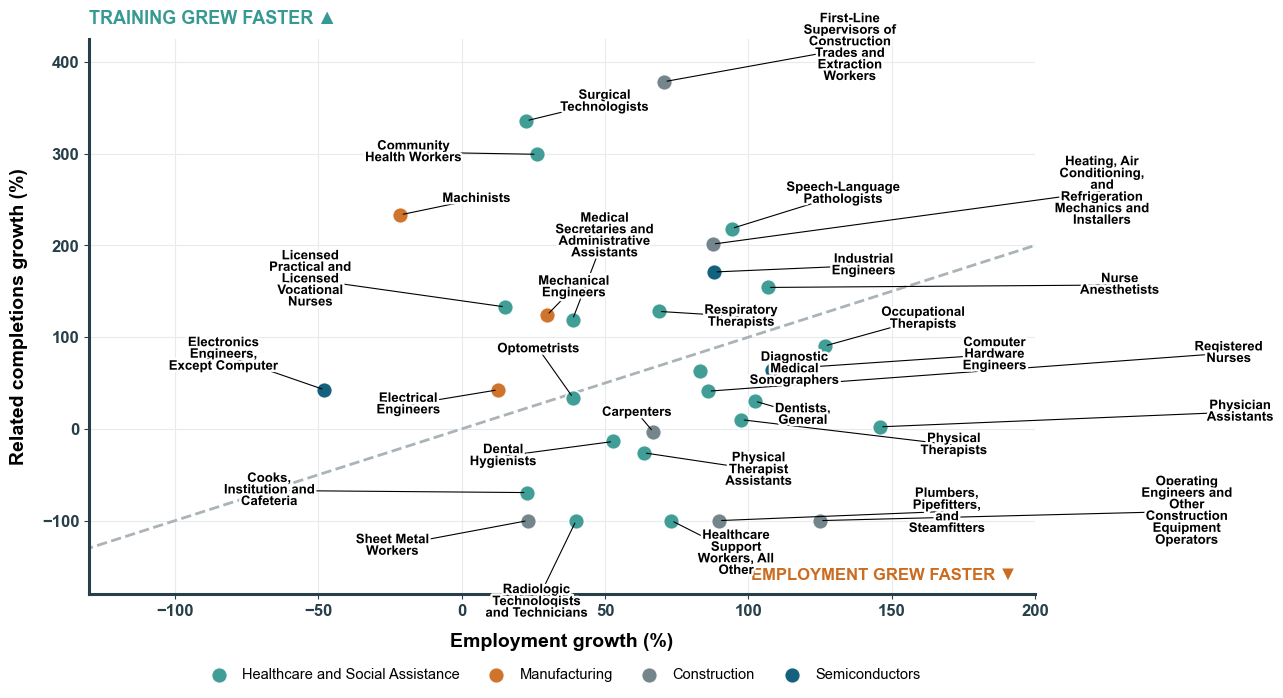

Saved figure: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Postsecondary_Training_Occupational_Alignment.png


In [20]:
# ============================================================
# 11. FIGURE. ARIZONA POST-SECONDARY TRAINING AND
#     OCCUPATIONAL ALIGNMENT FOR SELECT YEARS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

try:
    from adjustText import adjust_text
except ImportError as exc:
    raise ImportError(
        "This figure requires the adjustText package. "
        "Install it once with: pip install adjustText"
    ) from exc


# ------------------------------------------------------------
# PROJECT COLORS
# ------------------------------------------------------------

TEAL = "#369992"
ORANGE = "#CC6C20"
CONSTRUCTION = "#6E7F86"
DARK_TURQUOISE = "#075877"

BLACK = "#000000"
GRAY = "#AAB4B8"
LIGHT_GRAY = "#E7EBED"
WHITE = "#FFFFFF"

SECTOR_COLORS = {
    "Healthcare and Social Assistance": TEAL,
    "Manufacturing": ORANGE,
    "Construction": CONSTRUCTION,
    "Semiconductors": DARK_TURQUOISE,
}

SECTOR_LABELS = {
    "Healthcare and Social Assistance": "Healthcare and Social Assistance",
    "Manufacturing": "Manufacturing",
    "Construction": "Construction",
    "Semiconductors": "Semiconductors",
}


def wrap_label(text, width=15):
    """Wrap occupation labels into compact blocks."""

    import textwrap

    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width
        )
    )


plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 12,
        "axes.labelsize": 15,
        "axes.labelweight": "bold",
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.edgecolor": "#263F49",
        "xtick.color": "#263F49",
        "ytick.color": "#263F49",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


# ------------------------------------------------------------
# AXIS RANGE
# ------------------------------------------------------------
# Preserve the manuscript's familiar visual scale whenever possible.
# Expand automatically if a newly added Construction point requires it.

default_min_x = -130
default_max_x = 200
default_min_y = -180
default_max_y = 390

x_values = main[
    "employment_growth_pct_2014_2025"
]

y_values = main[
    "training_growth_pct_2014_2025"
]

minimum_x = min(
    default_min_x,
    np.floor(x_values.min() / 25) * 25 - 25
)

maximum_x = max(
    default_max_x,
    np.ceil(x_values.max() / 25) * 25 + 25
)

minimum_y = min(
    default_min_y,
    np.floor(y_values.min() / 25) * 25 - 25
)

maximum_y = max(
    default_max_y,
    np.ceil(y_values.max() / 25) * 25 + 25
)


# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7.5)
)

# Equal-growth reference line
line_min = min(
    minimum_x,
    minimum_y
)

line_max = max(
    maximum_x,
    maximum_y
)

ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    color=GRAY,
    linewidth=2.0,
    linestyle="--",
    zorder=1
)


# ------------------------------------------------------------
# SCATTER POINTS
# ------------------------------------------------------------

for sector in SECTOR_ORDER:

    sub = main[
        main["sector"].eq(sector)
    ]

    if sub.empty:
        continue

    ax.scatter(
        sub[
            "employment_growth_pct_2014_2025"
        ],
        sub[
            "training_growth_pct_2014_2025"
        ],
        s=130,
        color=SECTOR_COLORS[sector],
        edgecolor=WHITE,
        linewidth=1.2,
        alpha=0.95,
        label=SECTOR_LABELS[sector],
        zorder=3
    )


# ------------------------------------------------------------
# INTERPRETATION LABELS
# ------------------------------------------------------------

ax.text(
    0.0,
    1.02,
    "TRAINING GREW FASTER ▲",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    color=TEAL,
    ha="left",
    va="bottom"
)

ax.text(
    0.98,
    0.02,
    "EMPLOYMENT GREW FASTER ▼",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="bold",
    color=ORANGE,
    ha="right",
    va="bottom",
    zorder=4
)


# ------------------------------------------------------------
# OCCUPATION LABELS
# ------------------------------------------------------------

texts = []

for _, row in label_df.iterrows():

    x = row[
        "employment_growth_pct_2014_2025"
    ]

    y = row[
        "training_growth_pct_2014_2025"
    ]

    title = str(
        row["job_title"]
    ).strip()

    label = ax.text(
        x,
        y,
        wrap_label(
            title,
            width=15
        ),
        fontsize=9.5,
        fontweight="bold",
        color=BLACK,
        ha="center",
        va="center",
        linespacing=0.95,
        zorder=5
    )

    label.set_path_effects(
        [
            path_effects.withStroke(
                linewidth=3.5,
                foreground=WHITE
            )
        ]
    )

    texts.append(label)


adjust_text(
    texts,
    x=main[
        "employment_growth_pct_2014_2025"
    ].to_numpy(),
    y=main[
        "training_growth_pct_2014_2025"
    ].to_numpy(),
    ax=ax,
    only_move={
        "text": "xy",
        "static": "xy",
    },
    force_text=(1.2, 1.5),
    force_points=(2.0, 2.5),
    force_static=(1.0, 1.2),
    force_pull=(0.001, 0.001),
    expand=(1.15, 1.25),
    ensure_inside_axes=True,
    arrowprops=dict(
        arrowstyle="-",
        color=BLACK,
        linewidth=0.8,
        alpha=1.0,
        zorder=4
    ),
    iter_lim=4000
)


# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Employment growth (%)",
    labelpad=10,
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel(
    "Related completions growth (%)",
    labelpad=10,
    fontsize=14,
    fontweight="bold"
)

ax.set_xlim(
    minimum_x,
    maximum_x
)

ax.set_ylim(
    minimum_y,
    maximum_y
)

ax.grid(
    color=LIGHT_GRAY,
    linewidth=0.8
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

ax.spines["left"].set_color(
    "#263F49"
)

ax.spines["left"].set_linewidth(
    2.2
)

ax.spines["bottom"].set_color(
    "#263F49"
)

ax.spines["bottom"].set_linewidth(
    2.2
)

for tick_label in (
    ax.get_xticklabels()
    + ax.get_yticklabels()
):

    tick_label.set_fontweight(
        "bold"
    )


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=4,
    columnspacing=1.5,
    fontsize=10.5,
    handletextpad=0.6
)

fig.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.92,
    bottom=0.18
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "Saved figure:",
    OUTPUT_PNG
)


## 12. Output workbook

The Excel output is intended to make the figure fully auditable.

It contains:
- **Figure Data** — the exact occupation-level values behind the plotted figure
- **Excluded Display** — valid growth observations intentionally excluded only for visual readability
- **Undefined Growth** — occupations that cannot have a 2014–2025 percentage growth calculated because of a missing/zero baseline
- **CIP-SOC Relationships** — current master relationships used in the analysis
- **IPEDS QA** — source files, totals, and CIP conversion coverage
- **Lightcast QA** — employment-file matching checks

No migration analysis is included in this notebook because migration is a separate manuscript figure.


In [17]:
# ============================================================
# 12. EXPORT FIGURE DATA, INSTITUTION BREAKDOWN, AND QA
# ============================================================

with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl"
) as writer:

    # Primary manuscript figure data
    main.to_excel(
        writer,
        sheet_name="Figure Data",
        index=False
    )

    # Supporting Community College / University / Other analysis
    institution_type_alignment.to_excel(
        writer,
        sheet_name="By Institution Type",
        index=False
    )

    sector_type_summary.to_excel(
        writer,
        sheet_name="Sector-Type Summary",
        index=False
    )

    institution_classification.to_excel(
        writer,
        sheet_name="Institution Classification",
        index=False
    )

    # Figure QA
    excluded_from_display.to_excel(
        writer,
        sheet_name="Excluded Display",
        index=False
    )

    undefined_growth.to_excel(
        writer,
        sheet_name="Undefined Growth",
        index=False
    )

    cip_soc.to_excel(
        writer,
        sheet_name="CIP-SOC Relationships",
        index=False
    )

    ipeds_qa.to_excel(
        writer,
        sheet_name="IPEDS QA",
        index=False
    )

    lightcast_qa.to_excel(
        writer,
        sheet_name="Lightcast QA",
        index=False
    )

    for worksheet in writer.book.worksheets:

        worksheet.freeze_panes = "A2"

        worksheet.auto_filter.ref = (
            worksheet.dimensions
        )

        worksheet.sheet_view.showGridLines = False


print(
    "Saved workbook:",
    OUTPUT_EXCEL
)

print(
    "Saved figure:",
    OUTPUT_PNG
)

print(
    "\nNew supporting sheets:"
)

print(
    "  - By Institution Type"
)

print(
    "  - Sector-Type Summary"
)

print(
    "  - Institution Classification"
)


Saved workbook: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Postsecondary_Training_Occupational_Alignment.xlsx
Saved figure: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Postsecondary_Training_Occupational_Alignment.png

New supporting sheets:
  - By Institution Type
  - Sector-Type Summary
  - Institution Classification


### Figure. 2025 Related Completions Pipeline Share by Sector and Institution Type

> **Key Takeaways:**
> - **Healthcare & Social Assistance:** Universities produce the vast majority of related completions (70.8%), with the remainder split between Community Colleges (15.0%) and Other providers (14.3%).
> - **Manufacturing:** Heavily dominated by Universities (87.8%), with minor contributions from Community Colleges (6.7%) and Other providers (5.5%).
> - **Construction:** Exclusively driven by non-university providers—Other trade/technical institutions supply 73.6% of completions, while Community Colleges supply 26.4%.
> - **Semiconductors:** Led by Universities (85.1%) and supported by Community Colleges (14.9%), with zero completions from Other providers.

Workbook loaded successfully!
Columns: ['sector', 'soc', 'job_title', 'institution_type', 'related_completions_2014', 'related_completions_2019', 'related_completions_2025', 'training_growth_pct_2014_2025', 'employment_2014', 'employment_2019', 'employment_2025', 'employment_growth_pct_2014_2025', 'training_minus_employment_growth_pp']

--- 2025 Related Completions by Sector & Institution Type ---
institution_type                  Community College  Other  University
sector                                                                
Semiconductors                                  336      0        1921
Construction                                    844   2351           0
Manufacturing                                  1645   1350       21527
Healthcare and Social Assistance               1664   1586        7863

--- 2025 Percentage Share (%) ---
institution_type                  Community College  Other  University
sector                                                             

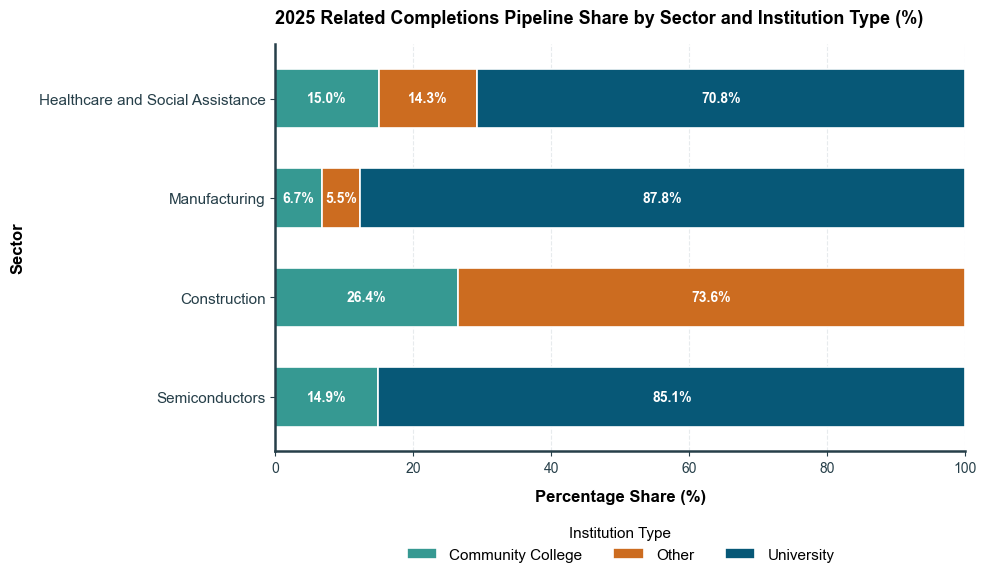


Saved image to: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Pipeline_Share_By_Institution_Type.png


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. FILE PATH & DATA LOADING
# =====================================================================
FILE_PATH = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Excel Sheets\Arielle Tables"
    r"\Figure_Postsecondary_Training_Occupational_Alignment.xlsx"
)

if not FILE_PATH.exists():
    raise FileNotFoundError(f"Excel workbook not found at:\n{FILE_PATH}")

# Read the "By Institution Type" sheet generated by Notebook 03
df_inst = pd.read_excel(FILE_PATH, sheet_name="By Institution Type")

print("Workbook loaded successfully!")
print("Columns:", df_inst.columns.tolist())

# =====================================================================
# 2. AGGREGATE COMPLETIONS BY SECTOR & INSTITUTION TYPE
# =====================================================================
# Sector and Institution Type Order
SECTOR_ORDER = [
    "Healthcare and Social Assistance",
    "Manufacturing",
    "Construction",
    "Semiconductors",
]

INSTITUTION_ORDER = [
    "Community College",
    "Other",
    "University",
]

# Pivot 2025 related completions
sector_piv = df_inst.pivot_table(
    index="sector",
    columns="institution_type",
    values="related_completions_2025",
    aggfunc="sum",
    fill_value=0
)

# Reindex to ensure consistent order (reversed for top-to-bottom horizontal bar chart)
sector_piv = sector_piv.reindex(SECTOR_ORDER[::-1])
sector_piv = sector_piv[INSTITUTION_ORDER]

# Compute percentage shares
sector_piv_pct = sector_piv.div(sector_piv.sum(axis=1), axis=0) * 100

print("\n--- 2025 Related Completions by Sector & Institution Type ---")
print(sector_piv)

print("\n--- 2025 Percentage Share (%) ---")
print(sector_piv_pct.round(1))

# =====================================================================
# 3. VISUALIZATION — 100% STACKED BAR CHART
# =====================================================================
# Project Colors
TEAL = "#369992"
ORANGE = "#CC6C20"
DARK_TURQUOISE = "#075877"
LIGHT_GRAY = "#E7EBED"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "axes.edgecolor": "#263F49",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

fig, ax = plt.subplots(figsize=(10, 6))

colors = [TEAL, ORANGE, DARK_TURQUOISE]

# Plot stacked horizontal bars
bars = sector_piv_pct.plot(
    kind="barh",
    stacked=True,
    color=colors,
    width=0.6,
    ax=ax,
    edgecolor="white",
    linewidth=1.2
)

# Add data labels inside the bar segments
for container in ax.containers:
    labels = [f"{val:.1f}%" if val > 4.5 else "" for val in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontweight="bold",
        fontsize=10
    )

# Formatting
ax.set_title(
    "2025 Related Completions Pipeline Share by Sector and Institution Type (%)",
    fontweight="bold",
    fontsize=13,
    pad=15,
    loc="left"
)
ax.set_xlabel("Percentage Share (%)", fontweight="bold", labelpad=10)
ax.set_ylabel("Sector", fontweight="bold", labelpad=10)
ax.set_xlim(0, 100)

ax.grid(axis="x", color=LIGHT_GRAY, linestyle="--", linewidth=0.8)
ax.set_axisbelow(True)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#263F49")
ax.spines["left"].set_linewidth(1.8)
ax.spines["bottom"].set_color("#263F49")
ax.spines["bottom"].set_linewidth(1.8)

# Legend
ax.legend(
    title="Institution Type",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    title_fontsize=11
)

plt.tight_layout()

# Save PNG image to output folder
output_img = FILE_PATH.parent / "Figure_Pipeline_Share_By_Institution_Type.png"
fig.savefig(output_img, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved image to: {output_img}")